# Business Understanding

## Project Domain

Proyek ini berada dalam domain Weather Forecasting & Agriculture Decision Support. Dalam beberapa dekade terakhir, perubahan iklim yang cepat telah memberikan dampak besar terhadap sektor pertanian. Petani, terutama di daerah agraris seperti Indonesia, sangat bergantung pada kondisi cuaca untuk mengambil keputusan penting seperti waktu tanam, jenis tanaman, hingga pola irigasi. Dalam konteks ini, prediksi cuaca yang akurat menjadi kebutuhan utama.

Dengan kemajuan teknologi dan ketersediaan data cuaca historis, kita dapat memanfaatkan algoritma machine learning untuk membuat model prediktif yang mampu mengklasifikasikan kondisi cuaca berdasarkan parameter-parameter cuaca seperti suhu, kelembaban, tekanan udara, dan kecepatan angin.

Proyek ini bertujuan untuk membangun sistem klasifikasi cuaca berbasis data, yang nantinya dapat digunakan untuk membantu petani, peneliti, atau lembaga pemerintahan dalam mengambil keputusan yang tepat di bidang pertanian.

## Problem Statements

Perubahan cuaca yang cepat dan tidak dapat diprediksi telah menyebabkan ketidakpastian yang signifikan dalam sektor pertanian. Banyak petani kesulitan dalam menentukan waktu yang tepat untuk menanam, menyiram, atau memanen karena kurangnya informasi yang akurat tentang cuaca dalam waktu dekat.

Secara umum, masalah utama dapat dirumuskan sebagai berikut:

"Bagaimana cara mengklasifikasikan kondisi cuaca (misalnya: cerah, berawan, hujan) secara otomatis dan akurat berdasarkan data historis parameter meteorologi, hasil prediksi tersebut dapat digunakan untuk mendukung pengambilan keputusan di sektor pertanian?"
. beberapa tantangan spesifik yang dihadapi antara lain:

. Ketersediaan data cuaca yang terstruktur dan representatif dari berbagai lokasi geografis.

. Menangani data yang tidak lengkap atau noisy dalam data cuaca historis.

. Membangun model klasifikasi yang dapat bekerja dengan akurasi tinggi (>90%).

. Menyajikan hasil prediksi dalam format yang mudah dipahami dan digunakan oleh pengguna non-teknis.

## Goals


Tujuan utama dari proyek ini adalah untuk membangun sistem klasifikasi cuaca berbasis data yang andal dan akurat, dengan sasaran akurasi model mencapai minimal 90%.

Secara lebih spesifik, tujuan dari proyek ini meliputi:

1. Pengumpulan dan eksplorasi data: Mengambil data cuaca historis dari Kaggle melalui API resmi menggunakan autentikasi dari file kaggle.json.

2. Pra-pemrosesan data: Membersihkan data, menangani nilai yang hilang, dan menyiapkan fitur-fitur yang akan digunakan dalam model prediktif.

3. Pemodelan machine learning: Menerapkan algoritma klasifikasi seperti Random Forest, Decision Tree, Support Vector Machine (SVM), atau Gradient Boosting untuk memprediksi kelas cuaca.

4. Evaluasi performa model: Menggunakan metrik seperti akurasi, precision, recall, dan confusion matrix untuk mengukur kinerja model.

5. Implementasi sistem prediksi: Membuat antarmuka atau aplikasi sederhana yang dapat menampilkan hasil prediksi dengan input dari pengguna atau sistem.

6. Rekomendasi berbasis cuaca: Memberikan saran atau peringatan yang relevan (misalnya, “tidak disarankan menanam hari ini karena kemungkinan hujan tinggi”) berdasarkan prediksi.

## Solution Statements

menyelesaikan masalah tersebut dan mencapai tujuan yang telah dirumuskan, solusi rancangan beikut:

1.Data Acquisition:

. Menggunakan akun dan autentikasi kaggle.json untuk mengakses dataset cuaca historis dari Kaggle (misalnya dataset seperti “Weather dataset”, “Daily weather data”, atau dataset nasional).

. Dataset harus memiliki fitur-fitur penting seperti: suhu maksimum dan minimum, kelembaban rata-rata, kecepatan angin, curah hujan, dan tekanan atmosfer.

2.Data Cleaning & Preprocessing:

. Menghapus atau mengisi nilai-nilai kosong/missing.

. Normalisasi/standardisasi fitur numerik agar sesuai untuk pemodelan.

. Label encoding pada target klasifikasi cuaca: {0 = Cerah, 1 = Berawan, 2 = Hujan}.

3.Model Training & Testing:

. Membagi dataset ke dalam training set dan test set (misalnya dengan rasio 80:20).

. Melatih beberapa model klasifikasi (Random Forest, SVM, Decision Tree, dll).

. Melakukan hyperparameter tuning (GridSearchCV atau RandomizedSearchCV).

4.Model Evaluation:

. Mengukur akurasi prediksi di test set.

. Menggunakan confusion matrix dan classification report untuk menilai kualitas prediksi per kelas.

. Jika model belum mencapai akurasi ≥90%, lakukan optimasi lebih lanjut atau coba ensemble learning.

5.Deployment & Decision Support:

. Menyediakan antarmuka (GUI, Web App, atau CLI) untuk pengguna akhir agar dapat memasukkan data cuaca secara manual atau otomatis (misal lewat API).

. Menampilkan hasil prediksi kondisi cuaca dalam bentuk yang ramah pengguna.

. Menyisipkan sistem saran berbasis aturan jika cuaca diprediksi ekstrem atau tidak mendukung kegiatan pertanian.

# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rijalbib","key":"6900497a9e119bd9b50cc597022db286"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d archanraef/data-cuaca

Dataset URL: https://www.kaggle.com/datasets/archanraef/data-cuaca
License(s): unknown


In [ ]:
!mkdir data-cuaca
!unzip data-cuaca.zip -d data-cuaca
!ls data-cuaca

Archive:  data-cuaca.zip
  inflating: data-cuaca/data_cuaca.csv  
data_cuaca.csv


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [ ]:
df = pd.read_csv('data-cuaca/data_cuaca.csv')


In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: []


In [ ]:
df.head()

,rowID,hpwren_timestamp,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
0,0,2011-09-10 00:00:49,912.3,64.76,97.0,1.2,106.0,1.6,85.0,1.0,NaN,NaN,60.5
1,1,2011-09-10 00:01:49,912.3,63.86,161.0,0.8,215.0,1.5,43.0,0.2,0.0,0.0,39.9
2,2,2011-09-10 00:02:49,912.3,64.22,77.0,0.7,143.0,1.2,324.0,0.3,0.0,0.0,43.0
3,3,2011-09-10 00:03:49,912.3,64.40,89.0,1.2,112.0,1.6,12.0,0.7,0.0,0.0,49.5
4,4,2011-09-10 00:04:49,912.3,64.40,185.0,0.4,260.0,1.0,100.0,0.1,0.0,0.0,58.8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587257 entries, 0 to 1587256
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   rowID               1587257 non-null  int64  
 1   hpwren_timestamp    1587257 non-null  object 
 2   air_pressure        1587257 non-null  float64
 3   air_temp            1587257 non-null  float64
 4   avg_wind_direction  1586824 non-null  float64
 5   avg_wind_speed      1586824 non-null  float64
 6   max_wind_direction  1586824 non-null  float64
 7   max_wind_speed      1586824 non-null  float64
 8   min_wind_direction  1586824 non-null  float64
 9   min_wind_speed      1586824 non-null  float64
 10  rain_accumulation   1587256 non-null  float64
 11  rain_duration       1587256 non-null  float64
 12  relative_humidity   1587257 non-null  float64
dtypes: float64(11), int64(1), object(1)
memory usage: 157.4+ MB


In [ ]:
df.describe()

,rowID,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
count,1.587257e+06,1.587257e+06,1.587257e+06,1.586824e+06,1.586824e+06,1.586824e+06,1.586824e+06,1.586824e+06,1.586824e+06,1.587256e+06,1.587256e+06,1.587257e+06
mean,7.936280e+05,9.168301e+02,6.185144e+01,1.619654e+02,2.774272e+00,1.634030e+02,3.399813e+00,1.668264e+02,2.133130e+00,1.854836e-03,5.361460e-01,4.760837e+01
std,4.582018e+05,3.051593e+00,1.183362e+01,9.520812e+01,2.060758e+00,9.236723e+01,2.423167e+00,9.746275e+01,1.745345e+00,9.609716e-01,8.114766e+01,2.621454e+01
min,0.000000e+00,9.050000e+02,3.164000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e-01
25%,3.968140e+05,9.148000e+02,5.270000e+01,6.200000e+01,1.300000e+00,6.800000e+01,1.600000e+00,7.700000e+01,8.000000e-01,0.000000e+00,0.000000e+00,2.470000e+01
50%,7.936280e+05,9.167000e+02,6.224000e+01,1.820000e+02,2.200000e+00,1.870000e+02,2.700000e+00,1.800000e+02,1.600000e+00,0.000000e+00,0.000000e+00,4.470000e+01
75%,1.190442e+06,9.187000e+02,7.088000e+01,2.170000e+02,3.800000e+00,2.230000e+02,4.600000e+00,2.120000e+02,3.000000e+00,0.000000e+00,0.000000e+00,6.800000e+01
max,1.587256e+06,9.295000e+02,9.950000e+01,3.590000e+02,3.230000e+01,3.590000e+02,3.600000e+01,3.590000e+02,3.200000e+01,6.550100e+02,6.330500e+04,9.300000e+01


In [ ]:
df.isnull().sum()

,0
rowID,0
hpwren_timestamp,0
air_pressure,0
air_temp,0
avg_wind_direction,433
avg_wind_speed,433
max_wind_direction,433
max_wind_speed,433
min_wind_direction,433
min_wind_speed,433


# Data Preparation

In [ ]:
df = df.dropna()

In [ ]:
def klasifikasi_cuaca(row):
    if row['rain_accumulation'] > 0:
        return 'Hujan'
    elif row['relative_humidity'] > 80:
        return 'Mendung'
    else:
        return 'Cerah'

In [ ]:
df['weather'] = df.apply(klasifikasi_cuaca, axis=1)

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['weather'])

In [ ]:
fitur = ['air_temp', 'relative_humidity', 'air_pressure', 'avg_wind_speed']
X = df[fitur]
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeling

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

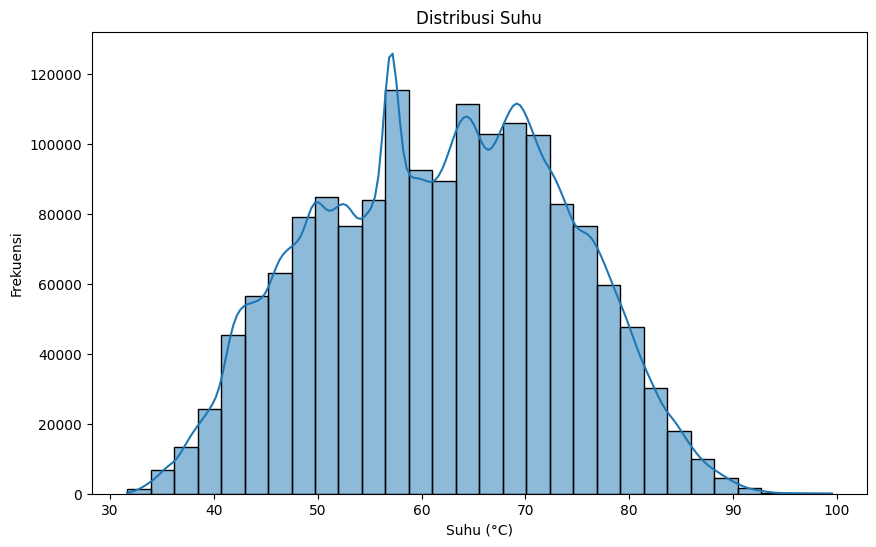

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['air_temp'], bins=30, kde=True) # Use the original DataFrame 'df' and the correct column name 'air_temp'
plt.title('Distribusi Suhu')
plt.xlabel('Suhu (°C)')
plt.ylabel('Frekuensi')
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,075 (43.26 KB)

 Trainable params: 11,075 (43.26 KB)

 Non-trainable params: 0 (0.00 B)

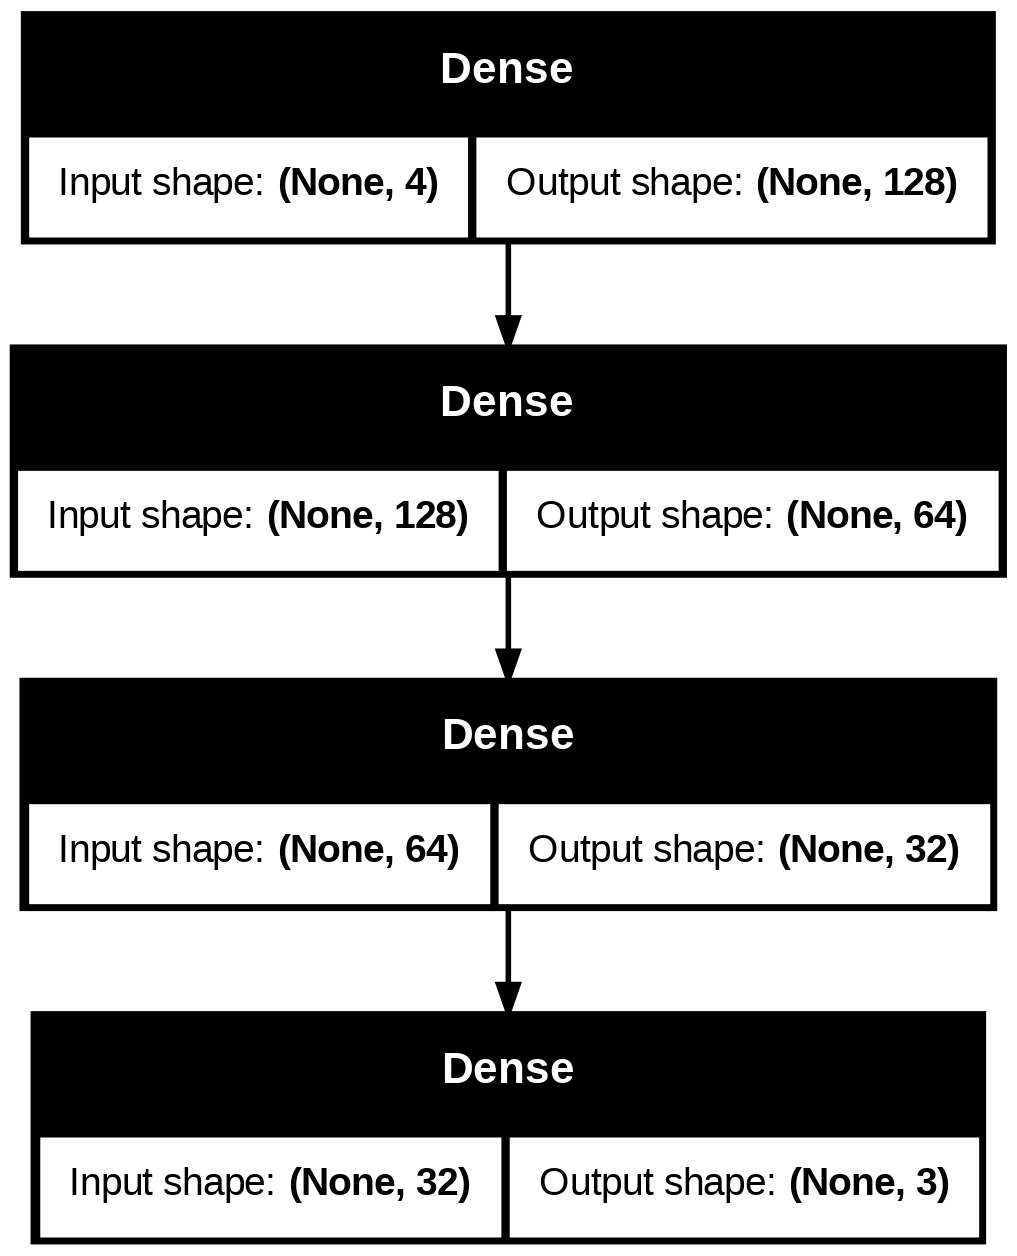

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [28]:
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 132s 3ms/step - accuracy: 0.9885 - loss: 0.0407 - val_accuracy: 0.9929 - val_loss: 0.0325
Epoch 2/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 128s 3ms/step - accuracy: 0.9897 - loss: 0.0377 - val_accuracy: 0.9897 - val_loss: 0.0355
Epoch 3/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 121s 3ms/step - accuracy: 0.9901 - loss: 0.0361 - val_accuracy: 0.9923 - val_loss: 0.0315
Epoch 4/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 143s 3ms/step - accuracy: 0.9905 - loss: 0.0351 - val_accuracy: 0.9905 - val_loss: 0.0341
Epoch 5/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 140s 3ms/step - accuracy: 0.9907 - loss: 0.0346 - val_accuracy: 0.9927 - val_loss: 0.0319
Epoch 6/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 126s 3ms/step - accuracy: 0.9908 - loss: 0.0343 - val_accuracy: 0.9919 - val_loss: 0.0308
Epoch 7/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 147s 3ms/step - accuracy: 0.9909 - loss: 0.0342 - val_accuracy: 0.9915 - val_loss: 0.0330
Epoch 8/20
39671/39671 ━━━━━━━━━━━━━━━━━━━━ 134s 3ms/step - ac

# Evaluation

In [29]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

9918/9918 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9927 - loss: 0.0299
Akurasi Model: 0.9925
Loss Model: 0.0302


In [30]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

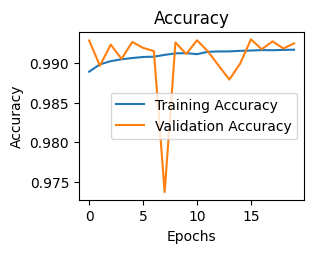

In [31]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

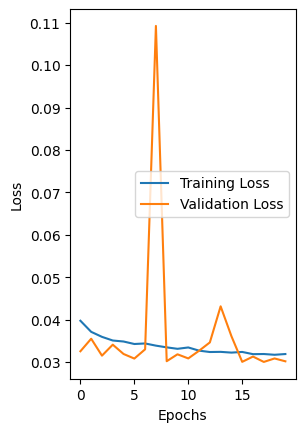

In [32]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

9918/9918 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step


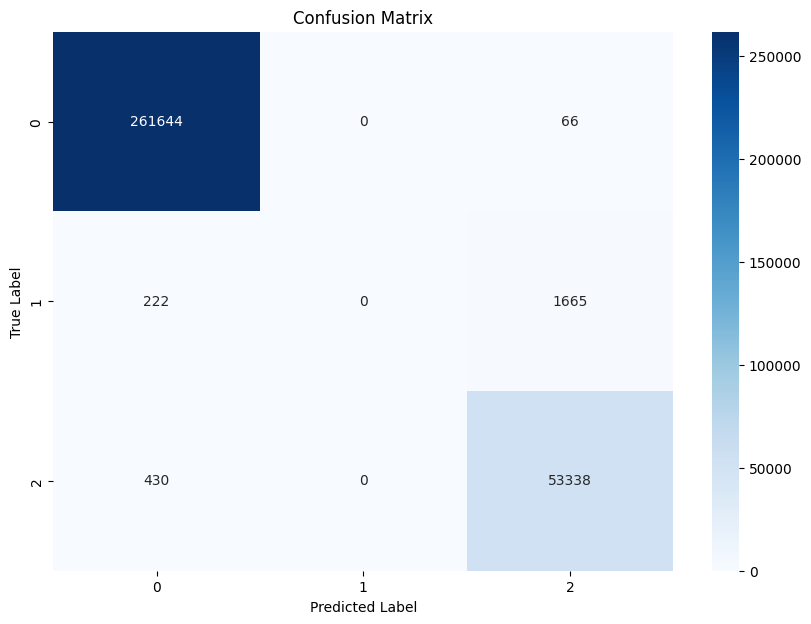

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    261710
           1       0.00      0.00      0.00      1887
           2       0.97      0.99      0.98     53768

    accuracy                           0.99    317365
   macro avg       0.66      0.66      0.66    317365
weighted avg       0.99      0.99      0.99    317365



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [48]:
# Assuming 'scaler' was fitted with features: 'air_temp', 'relative_humidity', 'air_pressure', 'avg_wind_speed'
# Create a sample input DataFrame with the correct feature names:
sample_input_df = pd.DataFrame([{
    'air_temp': 25,
    'relative_humidity': 80,
    'air_pressure': 1012,  # Replace with a typical value
    'avg_wind_speed': 2.0
}])

# Now you can use the scaler to transform the data:
sample_input_scaled = scaler.transform(sample_input_df)

In [49]:
sample_input_scaled = scaler.transform(sample_input_df)


In [50]:

predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Cuaca yang nice: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Cuaca yang nice: Mendung


## Save Model

In [51]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpkrp07yam'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139122461428624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139122461429776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139122461431504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139122461429200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139122461431696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139122461429008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139122461433424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139122461432272: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [47]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

['scaler.pkl']